<a href="https://colab.research.google.com/github/shivanshu-web/Bootcamp/blob/main/session5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [ ]:

df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)


       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [ ]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())



country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [ ]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4   Afghanistan  1972  13079460.0      Asia           36.088      739.981106
5   Afghanistan  1977  14880372.0      Asia           38.438             NaN
6   Afghanistan  1982  12881816.0      Asia           39.854      978.011439
7   Afghanistan  1987  13867957.0      Asia           40.822      852.395945
8   Afghanistan  1992  16317921.0      Asia           41.674      649.341395
9   Afghanistan  1997  22227415.0      Asia           41.763      635.341351
10  Afghanistan  2002  25268405.0      Asia           42.129      726.734055
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338

In [ ]:

# Year Range
print("Year Range:", df['year'].min(), "to", df['year'].max())

# Number of Countries
print("Number of Countries:", df['country'].nunique())

# Number of Continents
print("Number of Continents:", df['continent'].nunique())

print("Avrage life expectency ", df_clean["life_expectancy"].mean())



Year Range: 1952 to 2007
Number of Countries: 142
Number of Continents: 5
Avrage life expectency  59.474439366197174


In [ ]:
# grouping and counts
print(df_clean["continent"].value_counts())

continent_summary = df_clean


continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64


Latest year: 2007
        country  year  population continent  life_expectancy  gdp_per_capita
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338
23      Albania  2007   3600523.0    Europe           76.423     5937.029526
35      Algeria  2007  33333216.0    Africa           72.301     6223.367465
47       Angola  2007  12420476.0    Africa           42.731     4797.231267
59    Argentina  2007  40301927.0  Americas           75.320    12779.379640
(142, 6)


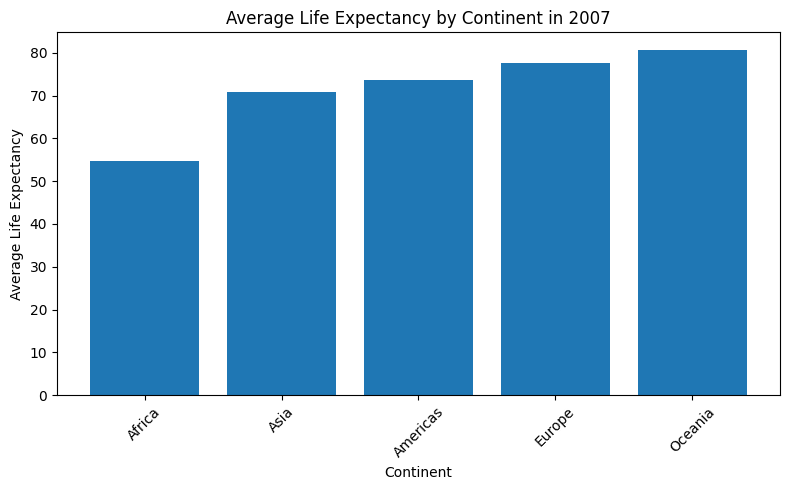

In [ ]:
# Step 1: Get the latest year and filter the dataset
latest_year = df_clean["year"].max()
latest_df = df_clean[df_clean["year"] == latest_year].copy()

print("Latest year:", latest_year)
print(latest_df.head())
print(latest_df.shape)

# Step 2: Group by continent and calculate the mean life expectancy
continent_life = latest_df.groupby("continent")["life_expectancy"].mean().sort_values()

# Step 3: Create the Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(continent_life.index, continent_life.values)

plt.title(f"Average Life Expectancy by Continent in {latest_year}")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

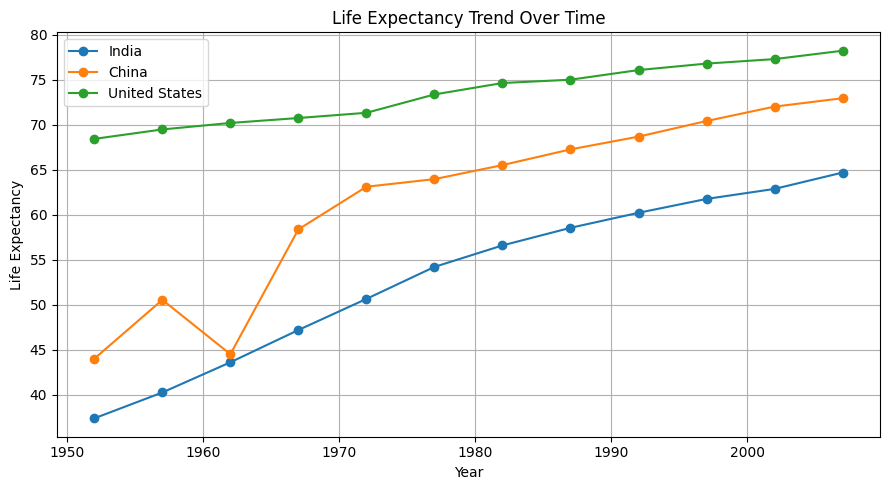

In [ ]:
# Step 1: Define the target countries and filter the dataset
selected_countries = ["India", "China", "United States"]
trend_df = df_clean[df_clean["country"].isin(selected_countries)]

# Step 2: Create the Line Chart using a loop
plt.figure(figsize=(9, 5))

for country in selected_countries:
    # Filter data specifically for the current country in the loop
    country_df = trend_df[trend_df["country"] == country]
    # Plot the line for this country
    plt.plot(country_df["year"], country_df["life_expectancy"], marker="o", label=country)

# Step 3: Add chart labels, legend, and layout settings
plt.title("Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

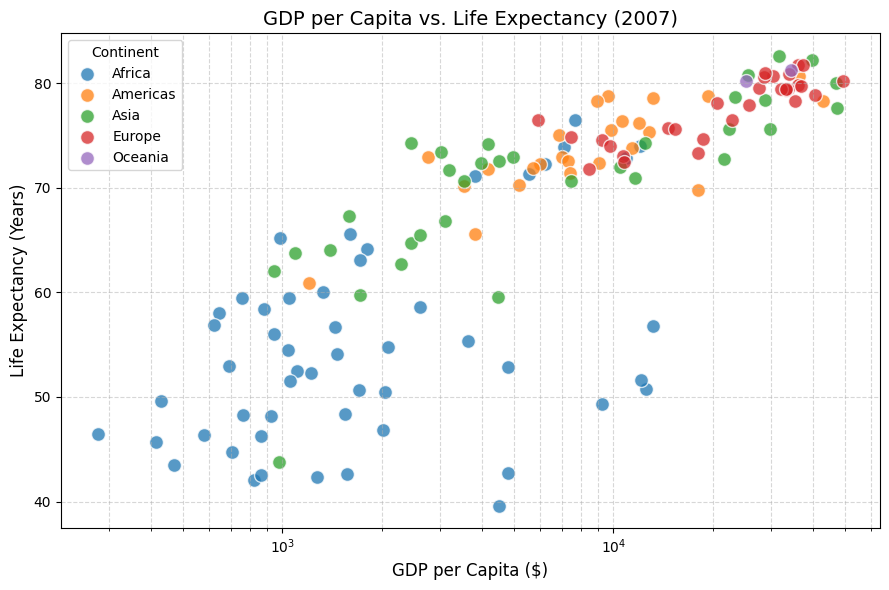

In [ ]:
# Create a scatter plot: GDP per Capita vs. Life Expectancy
plt.figure(figsize=(9, 6))

# Loop through each continent to plot them with unique colors automatically
for continent, group in latest_df.groupby("continent"):
    plt.scatter(
        group["gdp_per_capita"],
        group["life_expectancy"],
        label=continent,
        alpha=0.75,
        s=100,  # size of points
        edgecolors="white"
    )

# Customize the chart labels and appearance
plt.title(f"GDP per Capita vs. Life Expectancy ({latest_year})", fontsize=14)
plt.xlabel("GDP per Capita ($)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

# Optional: Apply logarithmic scale on X-axis since GDP varies exponentially
plt.xscale("log")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(title="Continent", fontsize=10)
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:
# Bar Chart (Continent Comparison): Oceania and Europe
#  have the highest average life expectancy ($75$–$80+$ years),
#   while Africa has the lowest (mid-$50$s), highlighting a major
#    global health gap.


# Line Chart (Country Trends): All countries improved
#  from 1952 to 2007. The US started high and grew steadily.
#   China and India started very low (under 45 years), but China
#   showed a massively sharp catch-up phase between 1960 and 1980.

#   Scatter Plot (Wealth vs. Health): There is a clear positive
#    link—higher GDP per capita means higher life expectancy. However,
#     it shows diminishing returns: once a country becomes wealthy,
#      further economic growth only leads to small, minor increases
#       in lifespan.